In [1]:
import sys
sys.path.append("../../src")
import os
import numpy as np
import pickle

import tensorflow as tf
tf.compat.v1.disable_v2_behavior()  # TF 2.x compatibility
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import pandas as pd
import math
import networkx as nx
from matplotlib.lines import Line2D   
from fast_pagerank import pagerank
from scipy import sparse   

import pickle
from natsort import natsorted

from utils_inference import evaluate_classification_results, evaluate_model_with_library, extract_and_save_weights
from autoencoder import full_network
from training import create_feed_dictionary
from cell_types_and_gene_utils import get_cell_type_data
%matplotlib inline

from glob import glob

c:\Users\Vasu\anaconda3\envs\sindy\lib\site-packages\tensorflow\python\framework\dtypes.py:523: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint8 = np.dtype([("qint8", np.int8, 1)])
c:\Users\Vasu\anaconda3\envs\sindy\lib\site-packages\tensorflow\python\framework\dtypes.py:524: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_quint8 = np.dtype([("quint8", np.uint8, 1)])
c:\Users\Vasu\anaconda3\envs\sindy\lib\site-packages\tensorflow\python\framework\dtypes.py:525: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint16 = np.dtype([("qint16", np.int16, 1)])
c:\Users\Vasu\anaconda3\envs\sindy\lib\site-packages\tensorflow\python\frame

In [2]:
class Errors:
    def __init__(self):
        self.decoder_x_error = None  # Initialize with an appropriate default value
        self.decoder_dx_error = None  # Initialize with an appropriate default value
        self.sindy_dz_error = None  # Initialize with an appropriate default value

    def calculate_relative_errors(self, test_data, model):
        self.decoder_x_error = np.mean((test_data['x'] - model['x_decode'])**2) / np.mean(test_data['x']**2)
        self.decoder_dx_error = np.mean((test_data['dx'] - model['dx_decode'])**2) / np.mean(test_data['dx']**2)
        self.sindy_dz_error = np.mean((model['dz'] - model['dz_predict'])**2) / np.mean(model['dz']**2)

    def print_errors(self):
        print('Decoder relative error: %f' % self.decoder_x_error)
        print('Decoder relative SINDy error: %f' % self.decoder_dx_error)
        print('SINDy relative error, z: %f' % self.sindy_dz_error)
        
class Experiment:
    def __init__(self):
        self.params = None
        self.save_name=None
        self.model={}
        self.idx=0
        self.errors=None

    def find_errors(self, test_data):
        self.errors=Errors()
        self.errors.calculate_relative_errors(test_data, self.model, )
        self.errors.print_errors()

class Experiments():
    def __init__ (self):
        self.experiments={}
    def add_experiment(self, num, exp):
        self.experiments[num] = exp
    def add_errors(self, num, test_data):
        self.experiments[num].find_errors(test_data)

In [8]:
chosen_dataset='Pancreas' #Choose from 'Bone Marrow','Pancreas','SERGIO'. Needs to be the directory name
result_dir_name='results'

root_dataset_files_path=f'../{chosen_dataset}'
result_dir_path=os.path.join(root_dataset_files_path,result_dir_name)

# Load the preprocessed time series
data_dict= pickle.load(open(os.path.join(root_dataset_files_path, 'time_series.pkl'),'rb'))

In [9]:
experiment_runs=[]
file_names = natsorted(glob(os.path.join(result_dir_path,'result_hyperparam','*.index')))
experiment_runs= [os.path.basename(file_name).split('.')[0] for file_name in file_names]

In [10]:
experiments=Experiments()
for exp_number, save_name in enumerate(experiment_runs):
    experiment=Experiment()
    data_path = os.getcwd() + '/'
    print(exp_number)
    experiment.params=pickle.load(open(os.path.join(result_dir_path,'result_hyperparam',save_name+'_params.pkl'),'rb'))
    experiment.save_name= os.path.join(result_dir_path,'result_hyperparam',save_name)
    tf.reset_default_graph()

    autoencoder_network = full_network(experiment.params)
    learning_rate = tf.placeholder(tf.float32, name='learning_rate')
    saver = tf.train.Saver(var_list=tf.get_collection(tf.GraphKeys.GLOBAL_VARIABLES))
    # temp_models={}fmodel
    
    tensorflow_run_tuple = ()
    new_keys={}
    # temp_models={}
    for key in autoencoder_network.keys():
            new_keys[key]=0
            tensorflow_run_tuple += (autoencoder_network[key],)
    with tf.Session() as sess:
        # Initialize global variables and restore the saved model
        sess.run(tf.global_variables_initializer())
        saver.restore(sess, experiment.save_name)
        
        # Create a feed dictionary for the test data
        test_dictionary = create_feed_dictionary(data_dict, experiment.params)
        
        # Execute the TensorFlow operations on the test data
        tf_results = sess.run(tensorflow_run_tuple, feed_dict=test_dictionary)

    for i, key in enumerate(autoencoder_network.keys()):
        # if key not in [ 'class_labels', 'class_score', 'classifier_weights', 'classifier_biases']:
           experiment.model[key]=tf_results[i]
    experiment.idx=exp_number
    experiments.add_experiment(exp_number, experiment)
    print("Errors")
    experiments.add_errors(exp_number, data_dict)
    

0
INFO:tensorflow:Restoring parameters from ../Pancreas\results\result_hyperparam\2024_05_06_02232817
Errors
Decoder relative error: 0.089475
Decoder relative SINDy error: 1.033765
SINDy relative error, z: 1.942631
1
INFO:tensorflow:Restoring parameters from ../Pancreas\results\result_hyperparam\2024_05_06_09806986
Errors
Decoder relative error: 0.087900
Decoder relative SINDy error: 1.048840
SINDy relative error, z: 2.865251
2
INFO:tensorflow:Restoring parameters from ../Pancreas\results\result_hyperparam\2024_05_06_10360686
Errors
Decoder relative error: 0.087834
Decoder relative SINDy error: 1.001904
SINDy relative error, z: 1.194942
3
INFO:tensorflow:Restoring parameters from ../Pancreas\results\result_hyperparam\2024_05_06_12951530
Errors
Decoder relative error: 0.086923
Decoder relative SINDy error: 1.018428
SINDy relative error, z: 1.663362
4
INFO:tensorflow:Restoring parameters from ../Pancreas\results\result_hyperparam\2024_05_06_13208539
Errors
Decoder relative error: 0.08747

The experiment chosen for analysis is experiment number 4-2024_05_06_13208539

In [11]:
selected_exp=4

In [12]:
# Retrieve parameters from the first experiment
params = experiments.experiments[0].params
# Run the evaluation
cross_index, active_terms, equations = evaluate_model_with_library(
    experiments=experiments,
    exp_number=selected_exp,
    params=params,
)



Evaluating Experiment 4
Misclassified samples: 9

Active Terms:
 LHS terms :RHS terms
{0: {3, 5}, 1: {3, 5}, 2: {3, 4, 5}, 3: {0, 1, 2, 3, 4, 5}, 4: {0, 1, 2, 3, 4, 5}, 5: {3, 5}}

Equation 0: dz0 = 0.22313*exp(z5) + -0.11732*z3*z3

Equation 1: dz1 = 0.31083*exp(z5) + -0.30699*z3*z3 + -0.27107*z3*z5

Equation 2: dz2 = 0.31627*z4 + -0.52275*exp(z5) + 0.27044*z3*z3 + 0.26667*z3*z4 + 0.32690*z4*z5

Equation 3: dz3 = 0.18136*z3 + 0.11561*z4 + 0.21107*exp(z4) + -0.18160*z0*z0 + -0.14156*z0*z2 + 0.07646*z1*z2 + 0.15135*z3*z3 + 0.15045*z3*z4 + 0.24897*z4*z4 + 0.84265*z4*z5

Equation 4: dz4 = -0.36528*z3 + -0.33925*exp(z1) + -0.10469*exp(z2) + 0.63967*exp(z5) + -0.38726*z0*z4 + -0.45365*z0*z5 + -0.23284*z1*z2 + -0.42662*z3*z3 + 0.51706*z3*z4 + 0.42512*z3*z5 + -0.45486*z4*z4 + -0.19883*z4*z5 + 0.29047*z5*z5

Equation 5: dz5 = 0.20992*exp(z5) + -0.11034*z3*z3


Save the model components for calculating the SHAP values

Experiment Number: 4

Confusion Matrix:
[[ 95   0   0   0   0   0   0]
 [  1 162   0   0   0   0   0]
 [  0   0 448   0   0   5   0]
 [  0   0   0  22   0   0   0]
 [  0   0   0   0 297   0   0]
 [  0   0   2   0   0 111   0]
 [  1   0   0   0   0   0 269]]

Classification Report:
               precision    recall  f1-score   support

        Alpha       0.98      1.00      0.99        95
         Beta       1.00      0.99      1.00       163
       Ductal       1.00      0.99      0.99       453
      Epsilon       1.00      1.00      1.00        22
 Ngn3 high EP       1.00      1.00      1.00       297
  Ngn3 low EP       0.96      0.98      0.97       113
Pre-endocrine       1.00      1.00      1.00       270

     accuracy                           0.99      1413
    macro avg       0.99      0.99      0.99      1413
 weighted avg       0.99      0.99      0.99      1413

Accuracy: 0.9936


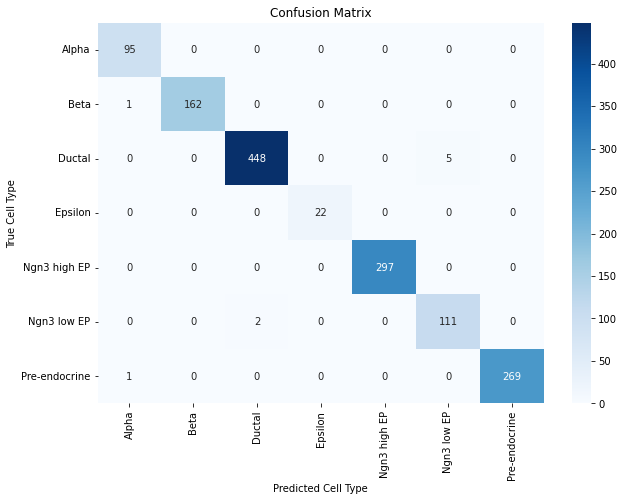

(0.9936305732484076,
 '               precision    recall  f1-score   support\n\n        Alpha       0.98      1.00      0.99        95\n         Beta       1.00      0.99      1.00       163\n       Ductal       1.00      0.99      0.99       453\n      Epsilon       1.00      1.00      1.00        22\n Ngn3 high EP       1.00      1.00      1.00       297\n  Ngn3 low EP       0.96      0.98      0.97       113\nPre-endocrine       1.00      1.00      1.00       270\n\n     accuracy                           0.99      1413\n    macro avg       0.99      0.99      0.99      1413\n weighted avg       0.99      0.99      0.99      1413\n',
 array([[ 95,   0,   0,   0,   0,   0,   0],
        [  1, 162,   0,   0,   0,   0,   0],
        [  0,   0, 448,   0,   0,   5,   0],
        [  0,   0,   0,  22,   0,   0,   0],
        [  0,   0,   0,   0, 297,   0,   0],
        [  0,   0,   2,   0,   0, 111,   0],
        [  1,   0,   0,   0,   0,   0, 269]], dtype=int64))

In [13]:
cell_types, index_to_clusters,_,_,_=get_cell_type_data('Pancreas')
evaluate_classification_results(experiments, selected_exp, index_to_clusters, save_path='confusion_matrix.pdf')

In [14]:
selected_exp = 4
experiment = experiments.experiments[selected_exp]

save_path=os.path.join(root_dataset_files_path,result_dir_name,'chosen_exp_components')
extract_and_save_weights(experiment, model_type='decoder', num_layers=2, save_path=save_path)
extract_and_save_weights(experiment, model_type='classifier', num_layers=1, save_path=save_path)


z_values=experiments.experiments[selected_exp].model['z']
with open(os.path.join(save_path,'z_values.pkl'), 'wb') as f:
    pickle.dump(z_values, f)

relevant_indices=[]
experiment=experiments.experiments[0]
for i in range(cell_types):
    relevant_indices.append(list(np.where(np.argmax(experiment.model['class_labels'],axis=1)==i)[0]))
with open(os.path.join(save_path,'index_to_class.pkl'), 'wb') as f:
    pickle.dump(relevant_indices, f)


with open(os.path.join(save_path, 'active_terms.pkl'),'wb') as f:
    pickle.dump(active_terms, f)